# Climate Temperature Anomaly Hexbin Density Map

Hexagonal binning (hexbin) divides coordinate planes into regular hexagons, counting measurements falling in each bin. This approach handles dense spatial overlays better than standard scatterplots, which suffer from overlapping marks. This notebook generates synthetic latitude/longitude temperature anomaly logs (5,000 measurements) and plots aggregates using a Matplotlib Hexbin plot.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate synthetic global temperature anomalies (5,000 spatial measurements)
np.random.seed(125)
n_points = 5000

# Generate coordinates centered around hot zones (e.g. Equator and dry regions)
lats = np.random.uniform(-60.0, 75.0, n_points)
lons = np.random.uniform(-150.0, 150.0, n_points)

# Temperature anomaly values: higher anomalies at high latitudes and land clusters
base_anomaly = np.sin(np.radians(lats)) * 1.5 + 0.8
noise = np.random.normal(0, 0.9, n_points)
anomalies = np.clip(base_anomaly + noise, -3.5, 4.0)

df_temp = pd.DataFrame({
    'Latitude': lats,
    'Longitude': lons,
    'Anomaly_C': anomalies
})

df_temp.head(10)



,Latitude,Longitude,Anomaly_C
0,8.408012,78.702190,1.342053
1,-52.233356,107.525807,-0.180980
2,24.723298,100.661346,1.184799
3,-42.105409,132.788200,0.029693
4,-42.303505,-62.987563,0.607216
5,46.453441,-133.249036,3.144365
6,8.402625,-38.023498,-0.171252
7,-4.268480,-72.442027,1.133563
8,18.031174,-29.052853,-0.131880
9,5.903545,-22.571272,-0.157408


## Spatial Statistics Summary

We calculate summary statistics for regional temperature anomalies.



In [2]:
print("Anomaly Temperature Distribution:")
df_temp['Anomaly_C'].describe()



Anomaly Temperature Distribution:


count    5000.000000
mean        0.933083
std         1.241989
min        -3.500000
25%         0.033238
50%         0.936998
75%         1.809567
max         4.000000
Name: Anomaly_C, dtype: float64

## Hexagonal Binning Density Visualization

We construct a spatial hexbin plot, specifying bin size, aggregating anomaly values using the mean, and coloring hexagons via a coolwarm scale.



<cell>:23: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



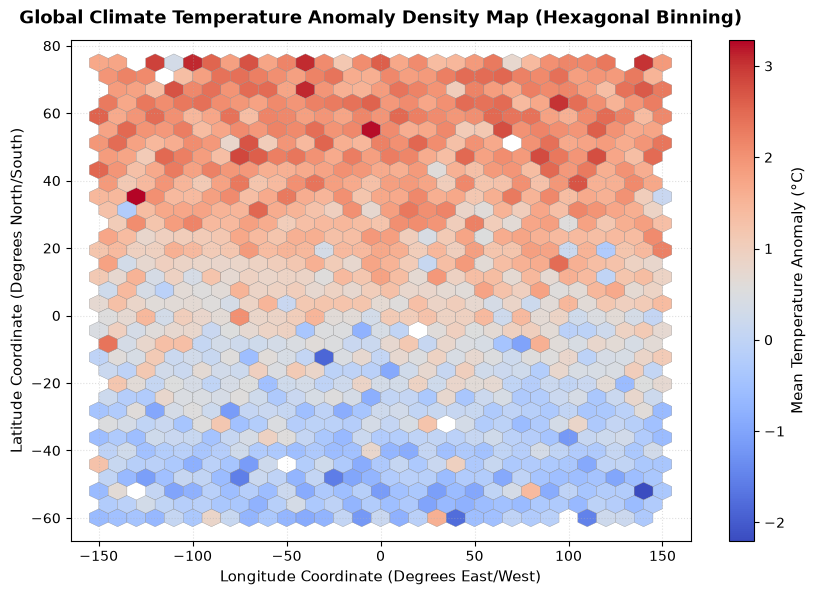

In [3]:
plt.figure(figsize=(10, 6.5))

# Plot hexbin
hb = plt.hexbin(
    df_temp['Longitude'], 
    df_temp['Latitude'], 
    C=df_temp['Anomaly_C'], # Aggregate anomaly values
    gridsize=30, 
    cmap='coolwarm', 
    reduce_C_function=np.mean, # Average values in each bin
    edgecolors='grey',
    linewidths=0.2
)

# Add colorbar representing temperature scale
cb = plt.colorbar(hb, spacing='uniform')
cb.set_label('Mean Temperature Anomaly (°C)', fontsize=11)

plt.title('Global Climate Temperature Anomaly Density Map (Hexagonal Binning)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Longitude Coordinate (Degrees East/West)', fontsize=11)
plt.ylabel('Latitude Coordinate (Degrees North/South)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()
